### Installing the required libaries

In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import seaborn  as sns
import matplotlib.pyplot as plt
from tabulate import tabulate

In [ ]:
df = pd.read_csv('formatted_data.csv')

In [6]:
df

,customer_id,tran_amount,response,trans_date,month
0,CS1937,98,0,25-12-2011,12
1,CS4671,49,0,02-04-2012,4
2,CS2080,49,1,19-07-2013,7
3,CS4418,60,0,22-09-2014,9
4,CS3229,68,0,26-02-2013,2
...,...,...,...,...,...
124964,CS8433,64,0,26-06-2011,6
124965,CS7232,38,0,19-08-2014,8
124966,CS8731,42,0,28-11-2014,11
124967,CS8133,13,0,14-12-2013,12


### Getting to know data types and other details

In [13]:
df.dtypes

customer_id    object
tran_amount     int64
response        int64
trans_date     object
month           int64
dtype: object

In [15]:
df.describe()

,tran_amount,response,month
count,124969.000000,124969.000000,124969.000000
mean,64.995143,0.110763,6.631725
std,22.860059,0.313840,3.475188
min,10.000000,0.000000,1.000000
25%,47.000000,0.000000,4.000000
50%,65.000000,0.000000,7.000000
75%,83.000000,0.000000,10.000000
max,105.000000,1.000000,12.000000


### Checking for Null values

In [18]:
df.isnull().sum()

customer_id    0
tran_amount    0
response       0
trans_date     0
month          0
dtype: int64

### Checking for outliers in Tran_amount and response

In [21]:
### zscore - to find any outliers

In [23]:
z_scores= np.abs(stats.zscore(df['tran_amount']))
#set a threshold

threshold = 3

outliers = z_scores>threshold

print (df[outliers])

Empty DataFrame
Columns: [customer_id, tran_amount, response, trans_date, month]
Index: []


In [25]:
z_scores= np.abs(stats.zscore(df['response']))

#set a threshold

threshold = 3

outliers = z_scores>threshold

print (df[outliers])

Empty DataFrame
Columns: [customer_id, tran_amount, response, trans_date, month]
Index: []


<function matplotlib.pyplot.show(close=None, block=None)>

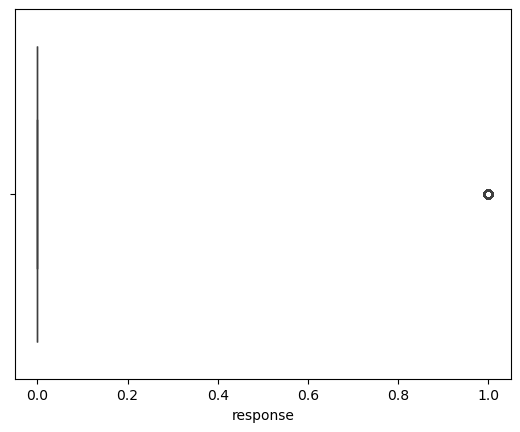

In [27]:
sns.boxplot(x=df['response'])
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

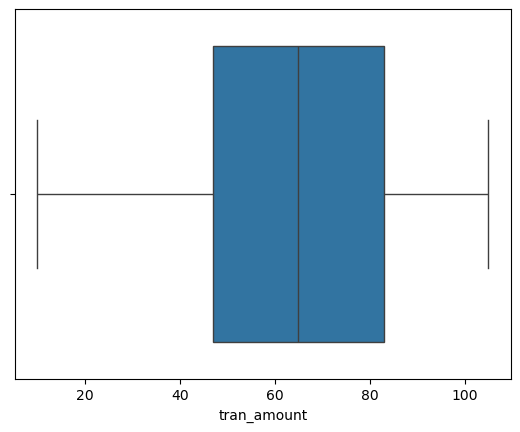

In [29]:
sns.boxplot(x=df['tran_amount'])
plt.show

### Data Analysis-Part

### Total Sales

In [33]:
total_sales = df['tran_amount']. sum()
total_sales

8122378

In [35]:
### formatting date column to pandas's 

In [37]:
df['trans_date'] = pd.to_datetime(df['trans_date'], dayfirst= 'true')
df

,customer_id,tran_amount,response,trans_date,month
0,CS1937,98,0,2011-12-25,12
1,CS4671,49,0,2012-04-02,4
2,CS2080,49,1,2013-07-19,7
3,CS4418,60,0,2014-09-22,9
4,CS3229,68,0,2013-02-26,2
...,...,...,...,...,...
124964,CS8433,64,0,2011-06-26,6
124965,CS7232,38,0,2014-08-19,8
124966,CS8731,42,0,2014-11-28,11
124967,CS8133,13,0,2013-12-14,12


In [39]:
### daily , monthly and yearly sales
### daily sales == to trans_date

In [41]:
daily_sales= df.groupby(df['trans_date'].dt.date)['tran_amount']. sum()
daily_sales

trans_date
2011-05-16    5755
2011-05-17    5570
2011-05-18    5698
2011-05-19    5779
2011-05-20    6018
              ... 
2015-03-12    5402
2015-03-13    5285
2015-03-14    4857
2015-03-15    6952
2015-03-16    6337
Name: tran_amount, Length: 1401, dtype: int64

In [43]:
### monthly_sales

In [45]:
monthly_sales= df.groupby('month')['tran_amount']. sum()

In [47]:
monthly_sales

month
1     724089
2     645028
3     636475
4     515746
5     633162
6     697014
7     717011
8     726775
9     694201
10    725058
11    698024
12    709795
Name: tran_amount, dtype: int64

In [49]:
type(monthly_sales.index)

pandas.core.indexes.base.Index

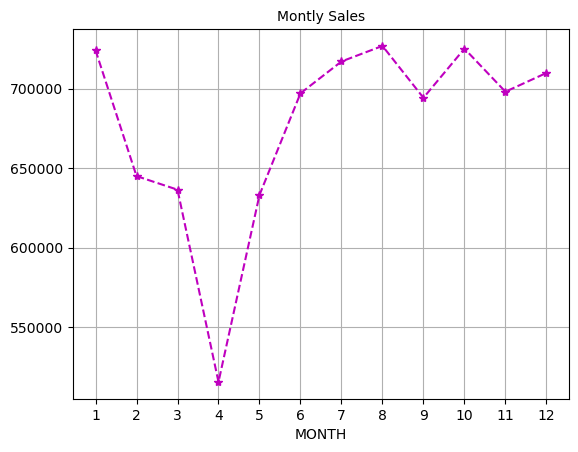

In [51]:
monthly_sales.index = monthly_sales.index.astype(str)
plt.plot(monthly_sales.index, monthly_sales.values,'*--m')
plt.xlabel('MONTH')
plt.title('Montly Sales', loc='center', size = 10)
plt.grid()
plt.show()

In [53]:
### yearly Sales

In [55]:
yearly_sales= df.groupby(df['trans_date'].dt.to_period('Y'))['tran_amount']. sum()
yearly_sales

trans_date
2011    1340013
2012    2115542
2013    2137140
2014    2094508
2015     435175
Freq: Y-DEC, Name: tran_amount, dtype: int64

In [57]:
type(yearly_sales.index)

pandas.core.indexes.period.PeriodIndex

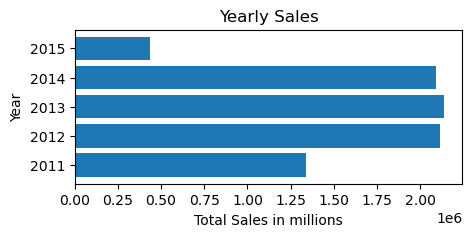

In [59]:
yearly_sales.index = yearly_sales.index.astype(str)
plt.figure(figsize=(5,2))
plt.barh(yearly_sales.index, yearly_sales.values)
plt.ylabel('Year')
plt.xlabel('Total Sales in millions')
plt.title('Yearly Sales')
plt.show()

### Response Effectiveness

In [62]:
### percentage who responed

In [64]:
total_response= df['response'].count()
print ("total_response:" , total_response)
print()
responed_count= df['response'].value_counts()
print ("responed_count:", responed_count)
print()
response_percentages = (responed_count / total_response) * 100
print ("response_percentages:", response_percentages)

total_response: 124969

responed_count: response
0    111127
1     13842
Name: count, dtype: int64

response_percentages: response
0    88.923653
1    11.076347
Name: count, dtype: float64


In [66]:
### average sales by response

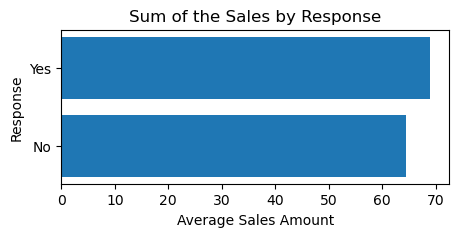

In [68]:
response_tran_amount = df[['response', 'tran_amount']]
average_sales = response_tran_amount.groupby('response')['tran_amount'].mean()
average_sales
xpoints = ['No', 'Yes']  
ypoints = average_sales.values  

plt.figure(figsize=(5,2))
plt.barh(xpoints, ypoints)  
plt.title('Sum of the Sales by Response')
plt.ylabel('Response')
plt.xlabel('Average Sales Amount')

plt.show()


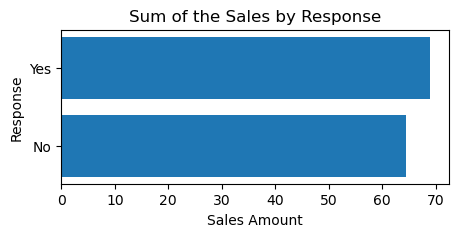

In [70]:
response_tran_amount = df[['response', 'tran_amount']]
sum_sales = response_tran_amount.groupby('response')['tran_amount'].sum()
xpoints = ['No', 'Yes']  
ypoints = average_sales.values  

plt.figure(figsize=(5,2))
plt.barh(xpoints, ypoints)  
plt.title('Sum of the Sales by Response')
plt.ylabel('Response')
plt.xlabel('Sales Amount')

plt.show()


In [72]:
### Total sales contributuion

In [74]:
total_sales_by_response = df.groupby('response')['tran_amount'].sum()
print(total_sales_by_response)
total_sales_percentage = (total_sales_by_response / total_sales_by_response.sum()) * 100
print("Total Sales Contribution by Response (in %):")
print(total_sales_percentage)

response
0    7166830
1     955548
Name: tran_amount, dtype: int64
Total Sales Contribution by Response (in %):
response
0    88.235613
1    11.764387
Name: tran_amount, dtype: float64


In [76]:
### top 10 spenders

In [78]:
spenders= df.groupby('customer_id')['tran_amount'].sum().reset_index()

top10spenders= spenders.sort_values(by='tran_amount',axis=0, ascending=False,inplace=False).head(10)
print("TOP 10 SPENDERS") 
top10spenders

TOP 10 SPENDERS


,customer_id,tran_amount
3312,CS4424,2933
3208,CS4320,2647
4640,CS5752,2612
3548,CS4660,2527
2687,CS3799,2513
3997,CS5109,2506
2962,CS4074,2462
2693,CS3805,2453
3496,CS4608,2449
4443,CS5555,2439


In [80]:
print(tabulate(top10spenders, headers='keys', tablefmt='pretty'))

+------+-------------+-------------+
|      | customer_id | tran_amount |
+------+-------------+-------------+
| 3312 |   CS4424    |    2933     |
| 3208 |   CS4320    |    2647     |
| 4640 |   CS5752    |    2612     |
| 3548 |   CS4660    |    2527     |
| 2687 |   CS3799    |    2513     |
| 3997 |   CS5109    |    2506     |
| 2962 |   CS4074    |    2462     |
| 2693 |   CS3805    |    2453     |
| 3496 |   CS4608    |    2449     |
| 4443 |   CS5555    |    2439     |
+------+-------------+-------------+


In [82]:
### bottom 10 spenders

In [84]:
last10spenders= spenders.sort_values(by='tran_amount',axis=0, ascending=False,inplace=False).tail(10)
print("Last 10 SPENDERS") 
last10spenders

Last 10 SPENDERS


,customer_id,tran_amount
5513,CS7627,195
5112,CS7224,191
6388,CS8504,190
5776,CS7891,188
6109,CS8224,187
6724,CS8841,181
5962,CS8077,164
6119,CS8234,157
6443,CS8559,157
5220,CS7333,149


In [86]:
### RFM analysis

In [88]:
### Recency

In [90]:
#Recency
recency= df.groupby('customer_id')['trans_date'].max().reset_index()
recency

,customer_id,trans_date
0,CS1112,2015-01-14
1,CS1113,2015-02-09
2,CS1114,2015-02-12
3,CS1115,2015-03-05
4,CS1116,2014-08-25
...,...,...
6879,CS8996,2014-12-09
6880,CS8997,2014-06-28
6881,CS8998,2014-12-22
6882,CS8999,2014-07-02


In [92]:
#frequency

In [94]:
frequency= df.groupby('customer_id')['trans_date'].count().reset_index()
frequency

,customer_id,trans_date
0,CS1112,15
1,CS1113,20
2,CS1114,19
3,CS1115,22
4,CS1116,13
...,...,...
6879,CS8996,13
6880,CS8997,14
6881,CS8998,13
6882,CS8999,12


In [96]:
#monetory

In [98]:
monetary= df.groupby('customer_id')['tran_amount'].sum().reset_index()
monetary

,customer_id,tran_amount
0,CS1112,1012
1,CS1113,1490
2,CS1114,1432
3,CS1115,1659
4,CS1116,857
...,...,...
6879,CS8996,582
6880,CS8997,543
6881,CS8998,624
6882,CS8999,383


In [100]:
#combine
rfm= pd.DataFrame({ 'customer_id': recency['customer_id'],
    'recency': recency['trans_date'],
    'frequency': frequency['trans_date'],
    'monetary': monetary['tran_amount']})
rfm

,customer_id,recency,frequency,monetary
0,CS1112,2015-01-14,15,1012
1,CS1113,2015-02-09,20,1490
2,CS1114,2015-02-12,19,1432
3,CS1115,2015-03-05,22,1659
4,CS1116,2014-08-25,13,857
...,...,...,...,...
6879,CS8996,2014-12-09,13,582
6880,CS8997,2014-06-28,14,543
6881,CS8998,2014-12-22,13,624
6882,CS8999,2014-07-02,12,383


In [102]:
rfm['R_rank'] = rfm['recency'].rank(ascending=False)
rfm['F_rank'] = rfm['frequency'].rank(ascending=True)
rfm['M_rank'] = rfm['monetary'].rank(ascending=True)
 
# normalizing the rank of the customers
rfm['R_rank_norm'] = (rfm['R_rank']/rfm['R_rank'].max())*100
rfm['F_rank_norm'] = (rfm['F_rank']/rfm['F_rank'].max())*100
rfm['M_rank_norm'] = (rfm['M_rank']/rfm['M_rank'].max())*100
 
rfm.drop(columns=['R_rank', 'F_rank', 'M_rank'], inplace=True)
rfm

,customer_id,recency,frequency,monetary,R_rank_norm,F_rank_norm,M_rank_norm
0,CS1112,2015-01-14,15,1012,53.987507,28.261185,34.914294
1,CS1113,2015-02-09,20,1490,36.780941,63.567693,72.574085
2,CS1114,2015-02-12,19,1432,34.369553,56.442475,67.540674
3,CS1115,2015-03-05,22,1659,13.909064,76.866647,84.449448
4,CS1116,2014-08-25,13,857,91.850668,17.257408,28.275712
...,...,...,...,...,...,...,...
6879,CS8996,2014-12-09,13,582,70.504067,17.257408,13.996223
6880,CS8997,2014-06-28,14,543,95.968913,22.494189,11.512202
6881,CS8998,2014-12-22,13,624,65.463393,17.257408,16.647298
6882,CS8999,2014-07-02,12,383,95.663858,12.659791,3.275712


In [104]:
### rfnscore= 0.15*Recency score + 0.28*Frequency score + 0.57 *Monetary score

In [106]:
rfm['RFM_Score'] = 0.15*rfm['R_rank_norm']+0.28 * rfm['F_rank_norm']+0.57*rfm['M_rank_norm']
rfm['RFM_Score'] *= 0.05
rfm= rfm.round(2)
rfm


,customer_id,recency,frequency,monetary,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score
0,CS1112,2015-01-14,15,1012,53.99,28.26,34.91,1.80
1,CS1113,2015-02-09,20,1490,36.78,63.57,72.57,3.23
2,CS1114,2015-02-12,19,1432,34.37,56.44,67.54,2.97
3,CS1115,2015-03-05,22,1659,13.91,76.87,84.45,3.59
4,CS1116,2014-08-25,13,857,91.85,17.26,28.28,1.74
...,...,...,...,...,...,...,...,...
6879,CS8996,2014-12-09,13,582,70.50,17.26,14.00,1.17
6880,CS8997,2014-06-28,14,543,95.97,22.49,11.51,1.36
6881,CS8998,2014-12-22,13,624,65.46,17.26,16.65,1.21
6882,CS8999,2014-07-02,12,383,95.66,12.66,3.28,0.99


In [108]:
rfm_table = rfm[['customer_id', 'RFM_Score']]
rfm_table

,customer_id,RFM_Score
0,CS1112,1.80
1,CS1113,3.23
2,CS1114,2.97
3,CS1115,3.59
4,CS1116,1.74
...,...,...
6879,CS8996,1.17
6880,CS8997,1.36
6881,CS8998,1.21
6882,CS8999,0.99


In [110]:
### Rating Customer based upon the RFM score
### rfm score >4.5 : Top Customer
### 4.5 > rfm score > 4 : High Value Customer
### 4>rfm score >3 : Medium value customer
### 3>rfm score>1.6 : Low-value customer
### rfm score<1.6 :Lost Customer

In [112]:
def assign_customer_segment(RFM_Score):
    if RFM_Score > 4.5:
        return "Top Customers"
    elif RFM_Score > 4:
        return "High Value Customer"
    elif RFM_Score > 3:
        return "Medium Value Customer"
    elif RFM_Score > 1.6:
        return "Low Value Customers"
    else:
        return "Lost Customers"

In [114]:
rfm['Segment'] = rfm['RFM_Score'].apply(assign_customer_segment)

In [116]:
rfm

,customer_id,recency,frequency,monetary,R_rank_norm,F_rank_norm,M_rank_norm,RFM_Score,Segment
0,CS1112,2015-01-14,15,1012,53.99,28.26,34.91,1.80,Low Value Customers
1,CS1113,2015-02-09,20,1490,36.78,63.57,72.57,3.23,Medium Value Customer
2,CS1114,2015-02-12,19,1432,34.37,56.44,67.54,2.97,Low Value Customers
3,CS1115,2015-03-05,22,1659,13.91,76.87,84.45,3.59,Medium Value Customer
4,CS1116,2014-08-25,13,857,91.85,17.26,28.28,1.74,Low Value Customers
...,...,...,...,...,...,...,...,...,...
6879,CS8996,2014-12-09,13,582,70.50,17.26,14.00,1.17,Lost Customers
6880,CS8997,2014-06-28,14,543,95.97,22.49,11.51,1.36,Lost Customers
6881,CS8998,2014-12-22,13,624,65.46,17.26,16.65,1.21,Lost Customers
6882,CS8999,2014-07-02,12,383,95.66,12.66,3.28,0.99,Lost Customers


In [118]:
### Chrun customers and active customers

In [120]:
churned_count = rfm[rfm['Segment'] == 'Lost Customers'].shape[0]
active_count = rfm[rfm['Segment'] != 'Lost Customers'].shape[0]

print("Number of Churned Customers:", churned_count)
print("Number of Active Customers:", active_count)

Number of Churned Customers: 1904
Number of Active Customers: 4980


In [122]:
### 10 customers have the highest total value of order
analysis1= df.groupby('customer_id')['tran_amount'].sum().reset_index()
top10_customers_valueoforder=analysis1.sort_values(by='tran_amount', ascending=False)
top10_customers_valueoforder

,customer_id,tran_amount
3312,CS4424,2933
3208,CS4320,2647
4640,CS5752,2612
3548,CS4660,2527
2687,CS3799,2513
...,...,...
6724,CS8841,181
5962,CS8077,164
6119,CS8234,157
6443,CS8559,157


In [124]:
### 10 customers have made the most purchases
analysis2= df['customer_id'].value_counts().reset_index()
top10_customers_mostpurchases=analysis2.sort_values(by='count',ascending=False)
top10_customers_mostpurchases

,customer_id,count
0,CS4424,39
1,CS4320,38
2,CS3799,36
3,CS2620,35
4,CS3805,35
...,...,...
6879,CS7224,4
6880,CS7716,4
6881,CS7333,4
6882,CS8559,4


In [126]:
### 3months have had highest transcation amount
analysis3= df.groupby('month')['tran_amount'].sum()
top3_highesttransaction=analysis3.sort_values(ascending=False).reset_index()
top3_highesttransaction

,month,tran_amount
0,8,726775
1,10,725058
2,1,724089
3,7,717011
4,12,709795
5,11,698024
6,6,697014
7,9,694201
8,2,645028
9,3,636475


In [128]:
### average transcations amount across all customers
average_transaction_amount = df['tran_amount'].mean()
average_transaction_amount=average_transaction_amount.round(3)
average_transaction_amount

64.995

In [130]:
### Number of customers have fall into each customer segment
segment_counts = rfm['Segment'].value_counts()
segment_counts

Segment
Low Value Customers      2426
Lost Customers           1904
Medium Value Customer    1679
High Value Customer       717
Top Customers             158
Name: count, dtype: int64

In [132]:
top_customers = rfm[rfm['Segment'] == 'Top Customers']['customer_id'].head(15)
print("Customer IDs of Top Customers:")
print(top_customers)

Customer IDs of Top Customers:
33     CS1145
67     CS1179
103    CS1215
125    CS1237
143    CS1255
148    CS1260
149    CS1261
220    CS1332
245    CS1357
255    CS1367
258    CS1370
261    CS1373
271    CS1383
285    CS1397
351    CS1463
Name: customer_id, dtype: object
